<a href="https://colab.research.google.com/github/zilzaniabdullahi1992-max/darul-hikma-school.vercel.app/blob/main/3.1_ATF26-659079-NGA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1.1: Probability & Neural Networks for Digital Twins

## Learning Objectives
- Understand how AI makes predictions using probability
- Learn the basics of neural networks
- Apply these concepts to building a digital twin

## Digital Twin Context
A **digital twin** is a virtual representation of a physical entity (person, object, system). In this series, we'll build a digital twin that can:
- Predict behaviors and preferences
- Understand and respond to language
- Learn from interactions

## Key Insight
> "AI isn't thinking; it's predicting the next number."

This applies to everything from weather prediction to language generation!

---
## Part 1: Probability Foundations

Let's start with the basics: How does AI make predictions?

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


### 1.1 Simple Prediction: Next Number

Let's simulate a digital twin predicting your next action based on historical data.

Activity Probabilities:
  Sleep: 20.00%
  Work: 40.00%
  Exercise: 13.33%
  Social: 13.33%
  Leisure: 13.33%


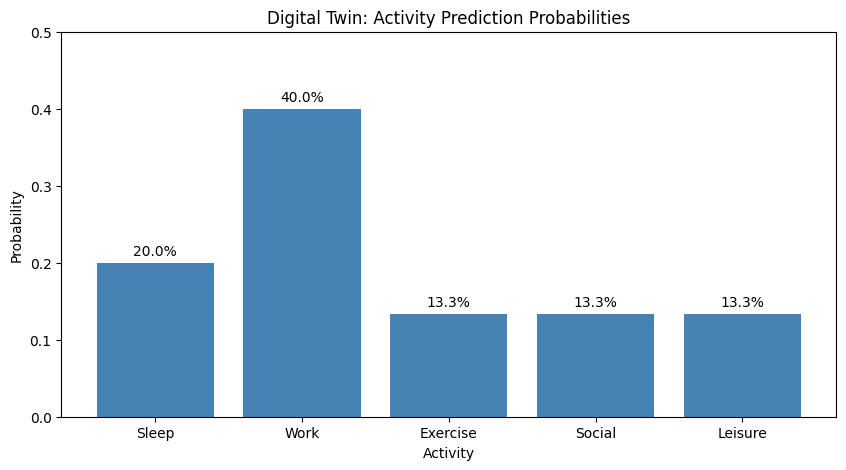

In [1]:
from collections import Counter
import matplotlib.pyplot as plt

# Example: Predicting daily activities (represented as numbers)
# 0=Sleep, 1=Work, 2=Exercise, 3=Social, 4=Leisure

historical_activities = [0, 1, 2, 1, 3, 1, 4, 0, 1, 2, 1, 3, 1, 4, 0]

def calculate_probabilities(sequence):
    """
    Calculate probability distribution from a sequence.

    Args:
        sequence: List of integers representing activities

    Returns:
        dict: Probability of each activity
    """
    counts = Counter(sequence)
    total = len(sequence)
    probabilities = {activity: count/total for activity, count in counts.items()}
    return probabilities

# Calculate probabilities
probs = calculate_probabilities(historical_activities)

# Display results
activity_names = {0: 'Sleep', 1: 'Work', 2: 'Exercise', 3: 'Social', 4: 'Leisure'}
print("Activity Probabilities:")
for activity, prob in sorted(probs.items()):
    print(f"  {activity_names[activity]}: {prob:.2%}")

# Visualize
plt.figure(figsize=(10, 5))
activities = [activity_names[k] for k in sorted(probs.keys())]
probabilities = [probs[k] for k in sorted(probs.keys())]
plt.bar(activities, probabilities, color='steelblue')
plt.title('Digital Twin: Activity Prediction Probabilities')
plt.ylabel('Probability')
plt.xlabel('Activity')
plt.ylim(0, 0.5)
for i, v in enumerate(probabilities):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')
plt.show()

### 🎯 Exercise 1.1 (Easy): Understanding Probabilities

**Task**: Modify the historical activities to represent your own daily routine for 2 weeks (14 days).

**Questions**:
1. Which activity has the highest probability?
2. What does this tell you about the pattern in your data?
3. How would adding more data points affect the predictions?

My Activity Probabilities:
  Sleep: 14.29%
  Work: 71.43%
  Exercise: 7.14%
  Leisure: 7.14%


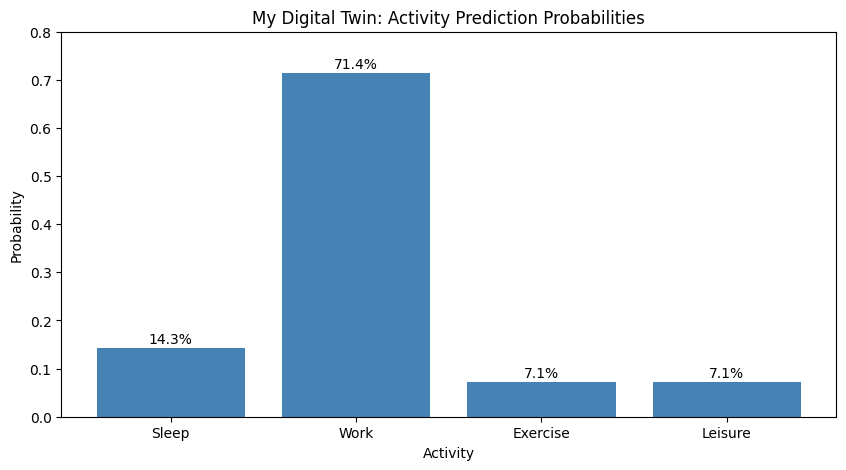

In [4]:
from collections import Counter
import matplotlib.pyplot as plt

# YADDA ZAKA MIKA (SUBMIT) AIKINKA:
# 1. Share Link: Danna 'Share' -> Canza zuwa 'Anyone with link' -> Kwafi link din ka mika.
# 2. Download File: Jeka File -> Download -> Sauke .ipynb sannan kayi upload.
# 3. Ajiye a GitHub: Jeka File -> Save a copy in GitHub idan bukatar hakan ta taso.

activity_names = {0: 'Sleep', 1: 'Work', 2: 'Exercise', 3: 'Social', 4: 'Leisure'}

def calculate_probabilities(sequence):
    counts = Counter(sequence)
    total = len(sequence)
    return {activity: count / total for activity, count in counts.items()}

# LAMBOBINKA NAN
my_activities = [0, 1, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 4]

my_probs = calculate_probabilities(my_activities)

print("My Activity Probabilities:")
for activity, prob in sorted(my_probs.items()):
    print(f"  {activity_names[activity]}: {prob:.2%}")

plt.figure(figsize=(10, 5))
activities = [activity_names[k] for k in sorted(my_probs.keys())]
probabilities = [my_probs[k] for k in sorted(my_probs.keys())]
plt.bar(activities, probabilities, color='steelblue')
plt.title('My Digital Twin: Activity Prediction Probabilities')
plt.ylabel('Probability')
plt.xlabel('Activity')
plt.ylim(0, 0.8)
for i, v in enumerate(probabilities):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')
plt.show()


### 1.2 Conditional Probability: Context Matters

What if predictions depend on previous activities? This is where context comes in!

In [ ]:
def calculate_conditional_probabilities(sequence):
    """
    Calculate P(next | current) - probability of next activity given current.

    Args:
        sequence: List of activities

    Returns:
        dict: Nested dictionary of conditional probabilities
    """
    transitions = {}

    for i in range(len(sequence) - 1):
        current = sequence[i]
        next_activity = sequence[i + 1]

        if current not in transitions:
            transitions[current] = []
        transitions[current].append(next_activity)

    # Convert to probabilities
    conditional_probs = {}
    for current, next_list in transitions.items():
        counts = Counter(next_list)
        total = len(next_list)
        conditional_probs[current] = {activity: count/total for activity, count in counts.items()}

    return conditional_probs

# Calculate conditional probabilities
cond_probs = calculate_conditional_probabilities(historical_activities)

# Display
print("Conditional Probabilities: P(Next | Current)\n")
for current, next_probs in cond_probs.items():
    print(f"After {activity_names[current]}:")
    for next_activity, prob in sorted(next_probs.items()):
        print(f"  → {activity_names[next_activity]}: {prob:.2%}")
    print()

Conditional Probabilities: P(Next | Current)

After Sleep:
  → Work: 100.00%

After Work:
  → Exercise: 33.33%
  → Social: 33.33%
  → Leisure: 33.33%

After Exercise:
  → Work: 100.00%

After Social:
  → Work: 100.00%

After Leisure:
  → Sleep: 100.00%



### 🎯 Exercise 1.2 (Intermediate): Markov Chain Prediction

**Task**: Build a simple predictor that uses conditional probabilities to predict the next activity.

**Challenge**: What happens after "Work"? Which activity is most likely?

In [5]:
from collections import Counter, defaultdict

activity_names = {0: 'Sleep', 1: 'Work', 2: 'Exercise', 3: 'Social', 4: 'Leisure'}

historical_activities = [0, 1, 2, 1, 3, 1, 4, 0, 1, 2, 1, 3, 1, 4, 0]

# Build conditional probabilities P(next | current)
def calculate_conditional_probabilities(sequence):
    transitions = defaultdict(Counter)
    for current, nxt in zip(sequence[:-1], sequence[1:]):
        transitions[current][nxt] += 1
    cond = {}
    for current, counter in transitions.items():
        total = sum(counter.values())
        cond[current] = {nxt: c / total for nxt, c in counter.items()}
    return cond

cond_probs = calculate_conditional_probabilities(historical_activities)

def predict_next_activity(current_activity, conditional_probs):
    if current_activity not in conditional_probs:
        return None
    next_probs = conditional_probs[current_activity]
    return max(next_probs, key=next_probs.get)

# Test your function
current = 1  # Work
predicted = predict_next_activity(current, cond_probs)
print(f"After {activity_names[current]}, most likely next: {activity_names.get(predicted, 'Unknown')}")

# BONUS: Predict a sequence of 5 activities starting from "Work"
def predict_sequence(start, conditional_probs, steps=5):
    seq = [start]
    for _ in range(steps):
        nxt = predict_next_activity(seq[-1], conditional_probs)
        if nxt is None:
            break
        seq.append(nxt)
    return seq

seq = predict_sequence(1, cond_probs, steps=5)
print("Predicted sequence:", " -> ".join(activity_names[a] for a in seq))

After Work, most likely next: Exercise
Predicted sequence: Work -> Exercise -> Work -> Exercise -> Work -> Exercise


---
## Part 2: Neural Networks Basics

Now let's see how neural networks learn to make predictions!

### 2.1 The Perceptron: Building Block of Neural Networks

A perceptron is the simplest neural network - it takes inputs, applies weights, and produces an output.

In [ ]:
import numpy as np

def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

def perceptron(inputs, weights, bias):
    """
    Simple perceptron implementation.

    Args:
        inputs: Array of input values
        weights: Array of weights
        bias: Bias term

    Returns:
        float: Output after activation
    """
    # Calculate weighted sum
    weighted_sum = np.dot(inputs, weights) + bias
    # Apply activation function
    output = sigmoid(weighted_sum)
    return output

# Example: Predicting if someone will exercise based on features
# Features: [hours_of_sleep, free_time_hours, energy_level (0-1)]
person_features = np.array([7, 2, 0.8])  # 7 hours sleep, 2 hours free time, high energy

# Initialize random weights
weights = np.array([0.3, 0.5, 0.7])
bias = -0.5

prediction = perceptron(person_features, weights, bias)
print(f"Probability of exercising: {prediction:.2%}")
print(f"Prediction: {'Will exercise' if prediction > 0.5 else 'Will not exercise'}")

Probability of exercising: 95.93%
Prediction: Will exercise


### 🎯 Exercise 2.1 (Easy): Feature Engineering

**Task**: Modify the features and observe how the prediction changes.

**Questions**:
1. What happens when sleep hours decrease to 4?
2. What if free time increases to 4 hours?
3. Which feature seems to have the most impact based on the weights?

In [6]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def perceptron(inputs, weights, bias):
    weighted_sum = np.dot(inputs, weights) + bias
    return sigmoid(weighted_sum)

weights = np.array([0.3, 0.5, 0.7])
bias = -0.5

# YOUR CODE HERE
test_cases = [
    np.array([4, 2, 0.8]),  # Low sleep
    np.array([7, 4, 0.8]),  # More free time
    np.array([7, 2, 0.3]),  # Low energy
]
labels = ["Low sleep (4h)", "More free time (4h)", "Low energy (0.3)"]

# Baseline
base = np.array([7, 2, 0.8])
print(f"Baseline {base}: {perceptron(base, weights, bias):.2%}")

# Test each case
for label, case in zip(labels, test_cases):
    p = perceptron(case, weights, bias)
    print(f"{label} {case}: {p:.2%} -> {'Will exercise' if p > 0.5 else 'Will not exercise'}")


Baseline [7.  2.  0.8]: 95.93%
Low sleep (4h) [4.  2.  0.8]: 90.55% -> Will exercise
More free time (4h) [7.  4.  0.8]: 98.46% -> Will exercise
Low energy (0.3) [7.  2.  0.3]: 94.32% -> Will exercise


### 2.2 Training a Simple Neural Network





Let's see how a network learns by adjusting weights!

In [8]:
class SimpleNeuralNetwork:
    """A simple neural network with one hidden layer."""

    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights randomly
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))

        # Store training history
        self.loss_history = []

    def forward(self, X):
        """Forward pass through the network."""
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output, learning_rate=0.1):
        """Backward pass - update weights."""
        m = X.shape[0]

        # Calculate gradients
        dz2 = output - y
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.a1 * (1 - self.a1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Update weights
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    def train(self, X, y, epochs=1000, learning_rate=0.1):
        """Train the network."""
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Calculate loss
            loss = np.mean((output - y) ** 2)
            self.loss_history.append(loss)

            # Backward pass
            self.backward(X, y, output, learning_rate)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        """Make predictions."""
        return self.forward(X)

# Create training data for digital twin
# Features: [day_of_week (0-6), time_of_day (0-23), weather (0-1), mood (0-1)]
# Target: [probability of social activity]

np.random.seed(42)
X_train = np.random.rand(100, 4)
# Simulate pattern: social activity more likely on weekends (day > 5) and good weather
y_train = ((X_train[:, 0] > 0.7) & (X_train[:, 2] > 0.5)).astype(float).reshape(-1, 1)
y_train += np.random.rand(100, 1) * 0.2  # Add noise
y_train = np.clip(y_train, 0, 1)

# Create and train network
nn = SimpleNeuralNetwork(input_size=4, hidden_size=8, output_size=1)
print("Training neural network...\n")
nn.train(X_train, y_train, epochs=500, learning_rate=0.5)

Training neural network...

Epoch 0, Loss: 0.5069
Epoch 100, Loss: 0.1061
Epoch 200, Loss: 0.0863
Epoch 300, Loss: 0.0678
Epoch 400, Loss: 0.0550


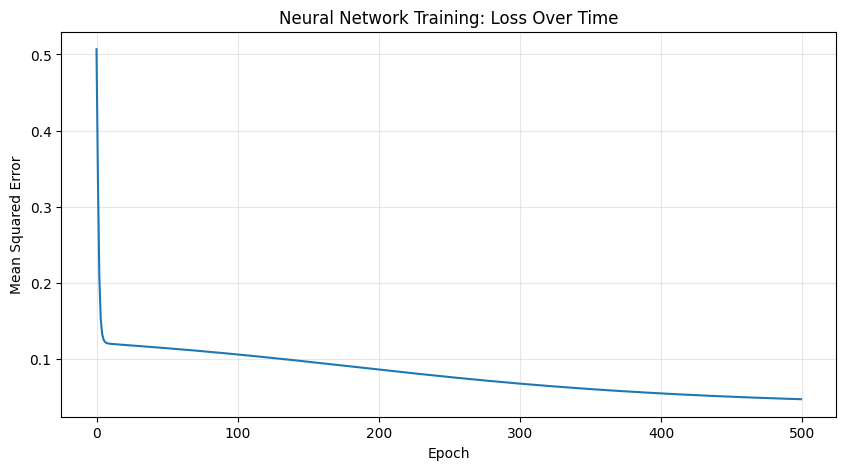


Final loss: 0.0474


In [9]:
# Visualize training progress
plt.figure(figsize=(10, 5))
plt.plot(nn.loss_history)
plt.title('Neural Network Training: Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal loss: {nn.loss_history[-1]:.4f}")

### 🎯 Exercise 2.2 (Intermediate): Digital Twin Prediction

**Task**: Test the trained network on new scenarios and interpret results.

**Scenarios to test**:
1. Weekend evening (day=6, time=18, weather=0.8, mood=0.9)
2. Weekday morning (day=2, time=8, weather=0.3, mood=0.5)
3. Weekend with bad weather (day=5, time=14, weather=0.2, mood=0.6)

In [11]:
import numpy as np

# ATF26-659079-NGA ZILZANI ABDULLAHI
def normalize_input(day, time, weather, mood):
    return np.array([[day/7, time/24, weather, mood]])

scenarios = [
    ("Weekend evening, good weather", 6, 18, 0.8, 0.9),
    ("Weekday morning, poor weather", 2, 8, 0.3, 0.5),
    ("Weekend afternoon, bad weather", 5, 14, 0.2, 0.6),
]

results = []
for name, day, time, weather, mood in scenarios:
    X_test = normalize_input(day, time, weather, mood)
    prediction = nn.predict(X_test)
    p = float(prediction[0][0])
    results.append((name, p))
    level = "High" if p > 0.7 else "Moderate" if p > 0.4 else "Low"
    print(f"{name}")
    print(f"  Social activity probability: {p:.2%} ({level})\n")

# Compare scenarios
best = max(results, key=lambda r: r[1])
worst = min(results, key=lambda r: r[1])
print(f"Highest: {best[0]} ({best[1]:.2%})")
print(f"Lowest:  {worst[0]} ({worst[1]:.2%})")


Weekend evening, good weather
  Social activity probability: 72.61% (High)

Weekday morning, poor weather
  Social activity probability: 6.27% (Low)

Weekend afternoon, bad weather
  Social activity probability: 22.70% (Low)

Highest: Weekend evening, good weather (72.61%)
Lowest:  Weekday morning, poor weather (6.27%)


### 🎯 Exercise 2.3 (Advanced): Improve the Digital Twin

**Task**: Enhance the neural network to make better predictions.

**Challenges**:
1. Add more training data with realistic patterns
2. Experiment with different network architectures (hidden layer size)
3. Try different learning rates
4. Add a second hidden layer
5. Create a visualization showing prediction accuracy

ARCHITECTURES (lr=0.5)
  (4, 4, 1): test accuracy = 74.00%, final loss = 0.5776
  (4, 8, 1): test accuracy = 73.00%, final loss = 0.5737
  (4, 16, 1): test accuracy = 74.00%, final loss = 0.5769
  (4, 16, 8, 1): test accuracy = 74.00%, final loss = 0.5781

LEARNING RATES (4, 8, 1)
  lr=0.01: test accuracy = 64.50%, final loss = 0.6657
  lr=0.1: test accuracy = 75.50%, final loss = 0.5959
  lr=0.5: test accuracy = 73.00%, final loss = 0.5737
  lr=1.0: test accuracy = 74.50%, final loss = 0.5636

Best architecture: (4, 4, 1)


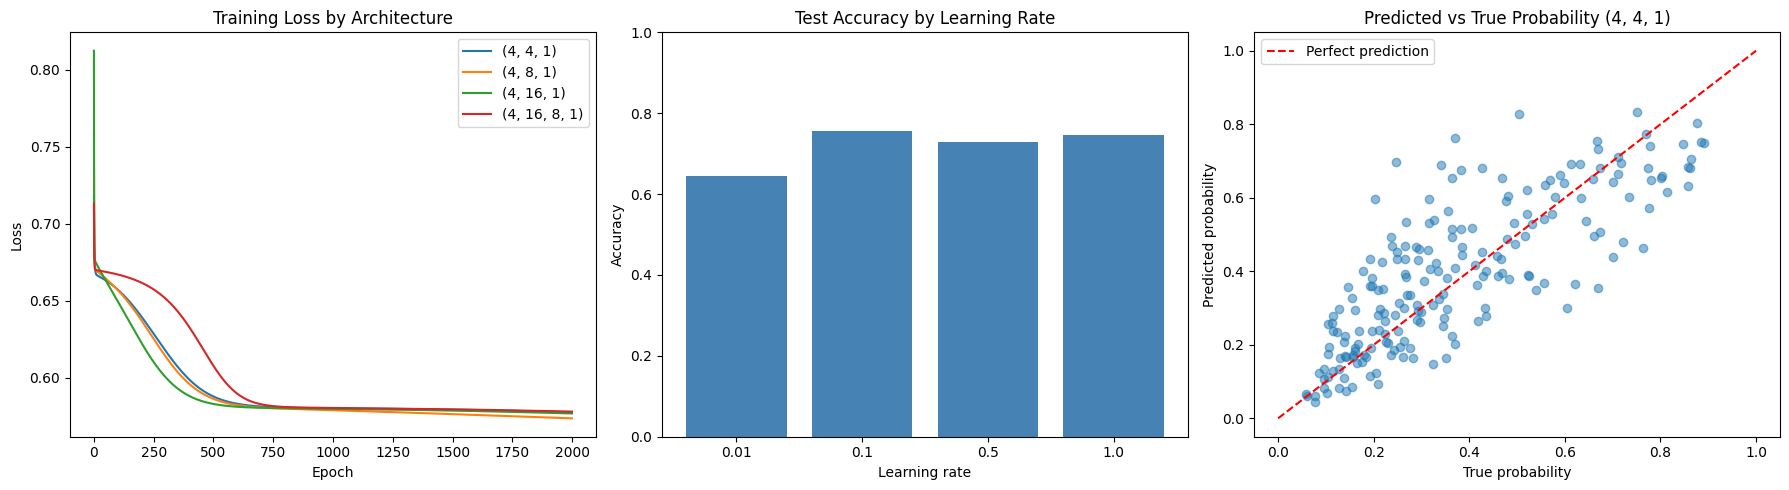


IMPROVED MODEL SCENARIOS
  Weekend evening, good weather: 84.06%
  Weekday morning, poor weather: 19.19%
  Weekend afternoon, bad weather: 48.99%


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 1. Realistic training data
def generate_realistic_data(n_samples=500, seed=42):
    """Day 0-6 (5,6 = weekend), time 0-24, weather 0-1, mood 0-1."""
    rng = np.random.default_rng(seed)
    day = rng.integers(0, 7, n_samples)
    time = rng.uniform(0, 24, n_samples)
    weather = rng.uniform(0, 1, n_samples)
    mood = rng.uniform(0, 1, n_samples)

    weekend = (day >= 5).astype(float)
    evening = np.exp(-((time - 18) / 4) ** 2)   # peaks around 6 PM

    logit = -3 + 1.5 * weekend + 2.0 * evening + 1.5 * weather + 1.5 * mood
    p_true = sigmoid(logit)                      # true social probability
    y = (rng.random(n_samples) < p_true).astype(float)

    X = np.column_stack([day / 7, time / 24, weather, mood])
    return X, y, p_true

# Flexible network (any number of hidden layers)
class NeuralNetwork:
    def __init__(self, layers, lr=0.5, seed=0):
        rng = np.random.default_rng(seed)
        self.lr = lr
        self.W = [rng.normal(0, np.sqrt(1 / layers[i]), (layers[i], layers[i + 1]))
                  for i in range(len(layers) - 1)]
        self.b = [np.zeros((1, layers[i + 1])) for i in range(len(layers) - 1)]

    def forward(self, X):
        acts = [X]
        for W, b in zip(self.W, self.b):
            acts.append(sigmoid(acts[-1] @ W + b))
        return acts

    def predict(self, X):
        return self.forward(X)[-1]

    def train(self, X, y, epochs=2000):
        y = y.reshape(-1, 1)
        m = len(X)
        losses = []
        for _ in range(epochs):
            acts = self.forward(X)
            out = acts[-1]
            losses.append(-np.mean(y * np.log(out + 1e-9) + (1 - y) * np.log(1 - out + 1e-9)))
            delta = out - y
            for i in reversed(range(len(self.W))):
                dW = acts[i].T @ delta / m
                db = delta.mean(axis=0, keepdims=True)
                if i > 0:
                    delta = (delta @ self.W[i].T) * acts[i] * (1 - acts[i])
                self.W[i] -= self.lr * dW
                self.b[i] -= self.lr * db
        return losses

def accuracy(nn, X, y):
    return np.mean((nn.predict(X).ravel() > 0.5) == y)

# Data + train/test split
X, y, p_true = generate_realistic_data(1000)
split = 800
X_tr, y_tr = X[:split], y[:split]
X_te, y_te, p_te = X[split:], y[split:], p_true[split:]

# 2 & 4. Architectures (including a second hidden layer)
architectures = [
    (4, 4, 1),       # Small
    (4, 8, 1),       # Medium
    (4, 16, 1),      # Large
    (4, 16, 8, 1),   # Two hidden layers
]
arch_results = {}
print("ARCHITECTURES (lr=0.5)")
for arch in architectures:
    nn = NeuralNetwork(arch, lr=0.5)
    losses = nn.train(X_tr, y_tr, epochs=2000)
    acc = accuracy(nn, X_te, y_te)
    arch_results[arch] = (nn, losses, acc)
    print(f"  {arch}: test accuracy = {acc:.2%}, final loss = {losses[-1]:.4f}")

# 3. Learning rates
lrs = [0.01, 0.1, 0.5, 1.0]
lr_results = {}
print("\nLEARNING RATES (4, 8, 1)")
for lr in lrs:
    nn = NeuralNetwork((4, 8, 1), lr=lr)
    losses = nn.train(X_tr, y_tr, epochs=2000)
    acc = accuracy(nn, X_te, y_te)
    lr_results[lr] = (losses, acc)
    print(f"  lr={lr}: test accuracy = {acc:.2%}, final loss = {losses[-1]:.4f}")

# Best model
best_arch = max(arch_results, key=lambda a: arch_results[a][2])
best_nn = arch_results[best_arch][0]
print(f"\nBest architecture: {best_arch}")

# 5. Visualizations
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# (a) Loss curves by architecture
for arch, (_, losses, _) in arch_results.items():
    ax[0].plot(losses, label=str(arch))
ax[0].set_title("Training Loss by Architecture")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend()

# (b) Accuracy by learning rate
ax[1].bar([str(lr) for lr in lrs], [lr_results[lr][1] for lr in lrs], color="steelblue")
ax[1].set_title("Test Accuracy by Learning Rate")
ax[1].set_xlabel("Learning rate"); ax[1].set_ylabel("Accuracy"); ax[1].set_ylim(0, 1)

# (c) Predicted vs true probability
pred = best_nn.predict(X_te).ravel()
ax[2].scatter(p_te, pred, alpha=0.5)
ax[2].plot([0, 1], [0, 1], "r--", label="Perfect prediction")
ax[2].set_title(f"Predicted vs True Probability {best_arch}")
ax[2].set_xlabel("True probability"); ax[2].set_ylabel("Predicted probability"); ax[2].legend()

plt.tight_layout()
plt.show()

# Re-test the Exercise 2.2 scenarios with the improved model
def normalize_input(day, time, weather, mood):
    return np.array([[day / 7, time / 24, weather, mood]])

scenarios = [
    ("Weekend evening, good weather", 6, 18, 0.8, 0.9),
    ("Weekday morning, poor weather", 2, 8, 0.3, 0.5),
    ("Weekend afternoon, bad weather", 5, 14, 0.2, 0.6),
]
print("\nIMPROVED MODEL SCENARIOS")
for name, d, t, w, m in scenarios:
    p = best_nn.predict(normalize_input(d, t, w, m))[0][0]
    print(f"  {name}: {p:.2%}")

---
## Part 3: Connecting to LLMs

How does this relate to Large Language Models?

### 3.1 From Activities to Words

LLMs work exactly like our activity predictor, but with words!

In [ ]:
# Simple word prediction example
text_sequence = "I love coding in Python because it is"
words = text_sequence.split()

# Simulate word prediction
word_vocab = ['fun', 'easy', 'powerful', 'versatile', 'simple', 'clear', 'elegant']
word_probs = np.random.rand(len(word_vocab))
word_probs = word_probs / word_probs.sum()  # Normalize to probabilities

# Create probability distribution
word_dist = dict(zip(word_vocab, word_probs))
word_dist = dict(sorted(word_dist.items(), key=lambda x: x[1], reverse=True))

print("Given text:", text_sequence)
print("\nPredicted next word probabilities:")
for word, prob in word_dist.items():
    print(f"  {word}: {prob:.2%}")

# Visualize
plt.figure(figsize=(12, 5))
plt.bar(word_dist.keys(), word_dist.values(), color='coral')
plt.title('LLM Word Prediction: P(next_word | context)')
plt.ylabel('Probability')
plt.xlabel('Candidate Words')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🎯 Exercise 3.1 (Conceptual): Understanding LLMs

**Questions**:
1. How is predicting the next word similar to predicting the next activity?
2. What role does probability play in both cases?
3. Why might an LLM sometimes generate unexpected words?
4. How does context (previous words) help make better predictions?

Write your answers in the cell below:

ID No: ATF26-659079-NGA
Name: ZILZANI ABDULLAHI
ANSWER:


1. Similarity between word and activity prediction:
Both are sequence prediction. The model looks at what has already happened (previous words or previous activities) and predicts what comes next. In the Markov exercise, "Work" led to a next activity. In an LLM, "The cat sat on the" leads to a next word like "mat". Both learn patterns from past data.

2. Role of probability:
In both cases the model does not pick one fixed answer. It assigns a probability to every possible next item (activity or word in the vocabulary), and the probabilities sum to 1. The most likely item can be chosen, or one can be sampled according to those probabilities. Sigmoid (single output) or softmax (many outputs) turns raw scores into these probabilities.

3. Unexpected generations:
- LLMs often sample from the distribution instead of always taking the top choice, so lower-probability words can be picked (especially with high temperature).
- Several words may have similar probabilities, so a small difference leads to a different path.
- Training data may be incomplete, biased, or rarely cover the situation, like the 0% Social activity in the small dataset.
- Each generated word becomes new context, so one unusual word can push the rest of the text in an unexpected direction.

4. Importance of context:
Context narrows down the possibilities. Without context, the model only knows overall frequencies (like the first exercise: Work 71%). With context, it uses conditional probability P(next | previous), which is much more accurate. For example, "bank" after "river" or after "money" leads to different next words. LLMs use long context (attention over many previous words), while the simple Markov model only used one previous activity.


**Your Answers:**

1. Similarity between word and activity prediction:
   -

2. Role of probability:
   -

3. Unexpected generations:
   -

4. Importance of context:
   -

---
## Summary & Key Takeaways

### What We Learned:
1. **Probability**: AI predicts by calculating probabilities based on historical patterns
2. **Conditional Probability**: Context matters - knowing what came before improves predictions
3. **Neural Networks**: Learn patterns by adjusting weights through training
4. **Digital Twin**: Can model behaviors using probabilistic predictions
5. **LLM Connection**: Language models are sophisticated versions of these basic concepts

### Next Steps:
In the next notebook, we'll explore:
- How LLMs represent words (embeddings)
- Transformer architecture
- Attention mechanisms
- Building a simple language model for your digital twin

---
## 🏆 Challenge Project (Advanced)

**Build Your Own Digital Twin Predictor**

Create a system that:
1. Collects data about your daily patterns (sleep, activities, mood, etc.)
2. Trains a neural network to predict your next likely activity
3. Evaluates prediction accuracy
4. Visualizes patterns it learned

**Bonus**: Add temporal features (day of week, time of day) and see how they improve predictions!

In [ ]:
# YOUR CHALLENGE PROJECT CODE HERE
# This is your space to be creative!
